# Competitor Pricing Walkthrough

This notebook is the **analysis** half of the `portfolio-showcase` pipeline. The
dashboard answers *"what is the price right now?"*; this notebook answers *"where
does each vendor sit, and what does the spread actually mean?"* — by opening the
pipeline's SQLite database directly and running queries the dashboard deliberately
does **not**.

**All pricing below is illustrative.** It was not collected from live vendor
sites; values are fixed at `data_as_of: 2026-10-01`, and the vendor names describe
a realistic scenario only. This project is not affiliated with, endorsed by, or
acting on behalf of any vendor mentioned.

**Route through the notebook:** load the seeded database → confirm the schema and
coverage → compare price per SKU across four vendors → quantify the spread and the
cheapest option per SKU → close with how this would run in production.


In [1]:
# --- Setup -------------------------------------------------------------------
# Find the repository root by walking up from the kernel's working directory
# until the shared import bootstrap appears. Notebooks have no __file__, so this
# is how the notebook locates the repo without hard-coding a path.
from pathlib import Path
import sys

repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / "import_paths.py").exists():
    repo_root = repo_root.parent
assert (repo_root / "import_paths.py").exists(), "run this notebook from inside the repo"

# The single documented bootstrap: put pricing-scraper/ on sys.path, then import
# the shared data-layer modules by name (they are not an installable package).
sys.path.insert(0, str(repo_root))
from import_paths import add_pricing_scraper_to_path  # noqa: E402

add_pricing_scraper_to_path()

from schema import connect  # noqa: E402
from scraper import seed_from_json  # noqa: E402

import pandas as pd  # noqa: E402

DATA_FILE = repo_root / "pricing-scraper" / "sample_data.json"
DB_PATH = repo_root / "pricing-scraper" / "data" / "market_data.db"

# Idempotent: build and seed the database if it is not present, so a fresh clone
# can run this notebook with no manual step. Re-running changes nothing.
if not DB_PATH.exists():
    seed_from_json(DB_PATH, DATA_FILE)
    print(f"seeded a new database at {DB_PATH.relative_to(repo_root)}")

conn = connect(DB_PATH)
# Report the location by name, never as an absolute local path, so the stored
# output carries no machine-specific directory.
print("repo root :", repo_root.name)
print("database  :", DB_PATH.relative_to(repo_root))
print("tables    :", [r[0] for r in conn.execute(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name")])


repo root : portfolio-showcase
database  : pricing-scraper/data/market_data.db
tables    : ['competitors', 'pricing_history', 'pricing_snapshots', 'products', 'sqlite_sequence']


## 1 · What the pipeline actually stored

Four tables. `pricing_history` is the interesting one: every row is a price
**observation** carrying a validity window (`valid_from` / `valid_to`). A row whose
`valid_to IS NULL` is the price that is *current* as of the seed date — the exact
filter the dashboard uses. We start by pulling that current view into a dataframe.


In [2]:
# The "current price" view: exactly one open validity window per (vendor, SKU).
current = pd.read_sql_query(
    """
    SELECT c.name     AS vendor,
           p.sku      AS sku,
           p.name     AS plan,
           p.category AS category,
           ph.price   AS price
      FROM pricing_history AS ph
      JOIN competitors AS c ON c.id = ph.competitor_id
      JOIN products    AS p ON p.id = ph.product_id
     WHERE ph.valid_to IS NULL
    """,
    conn,
)

print(
    f"{len(current)} current observations across "
    f"{current['vendor'].nunique()} vendors and {current['sku'].nunique()} SKUs"
)
current.head(8)


19 current observations across 4 vendors and 5 SKUs


,vendor,sku,plan,category,price
0,DigitalOcean,nano,1 vCPU / 1 GB,shared,6.0
1,DigitalOcean,small,1 vCPU / 2 GB,shared,12.0
2,DigitalOcean,medium,2 vCPU / 4 GB,shared,24.0
3,DigitalOcean,large,4 vCPU / 8 GB,general-purpose,48.0
4,DigitalOcean,xlarge,8 vCPU / 16 GB,general-purpose,96.0
5,Linode,nano,1 vCPU / 1 GB,shared,5.0
6,Linode,small,1 vCPU / 2 GB,shared,12.0
7,Linode,medium,2 vCPU / 4 GB,shared,24.0


## 2 · Positioning — price per SKU, vendor by vendor

Pivot the current view into a SKU × vendor grid. One row per plan size (ordered
smallest to largest, not alphabetically), one column per vendor. A blank cell is
not zero — it means that vendor does not publish a comparable SKU (which is
itself a finding, revisited in §4).


In [3]:
# Fixed orders: plan sizes run small→large; vendors keep the seed file's order so
# charts read consistently across sections.
SKU_ORDER = ["nano", "small", "medium", "large", "xlarge"]
VENDOR_ORDER = ["DigitalOcean", "Linode", "Vultr", "Hetzner"]

grid = (
    current.pivot(index="sku", columns="vendor", values="price")
    .reindex(index=SKU_ORDER, columns=VENDOR_ORDER)
)

print("Price grid (USD / month):")
grid.round(2)


Price grid (USD / month):


vendor,DigitalOcean,Linode,Vultr,Hetzner
sku,,,,
nano,6.0,5.0,5.0,NaN
small,12.0,12.0,10.0,4.59
medium,24.0,24.0,18.0,5.99
large,48.0,48.0,36.0,8.99
xlarge,96.0,96.0,72.0,16.99


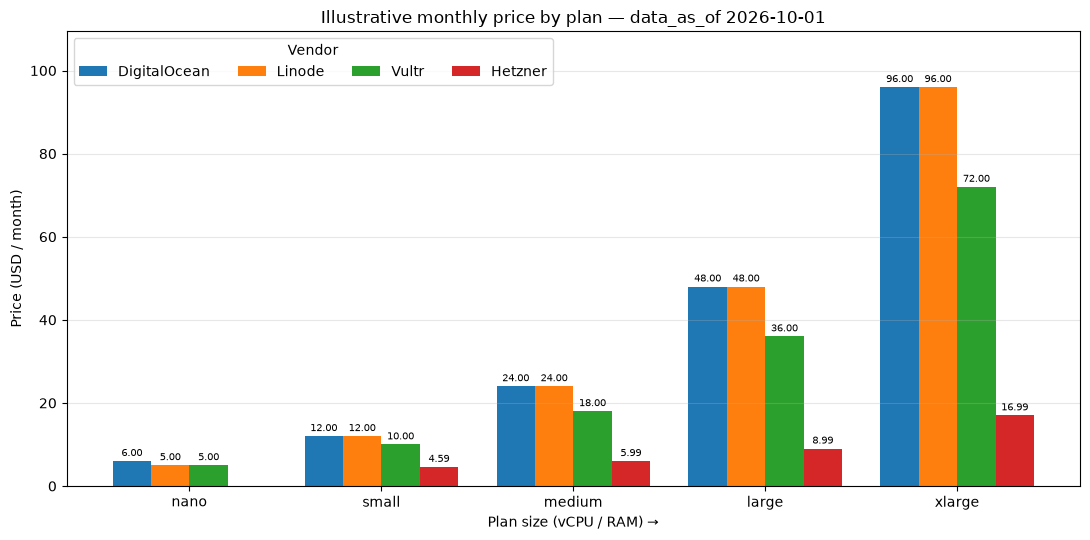

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 5.5))
positions = range(len(SKU_ORDER))
width = 0.2

for i, vendor in enumerate(VENDOR_ORDER):
    offset = (i - (len(VENDOR_ORDER) - 1) / 2) * width
    bars = ax.bar([p + offset for p in positions], grid[vendor], width=width, label=vendor)
    ax.bar_label(bars, fmt="%.2f", fontsize=7, padding=2)

ax.set_xticks(list(positions))
ax.set_xticklabels(SKU_ORDER)
ax.set_xlabel("Plan size (vCPU / RAM) →")
ax.set_ylabel("Price (USD / month)")
ax.set_title("Illustrative monthly price by plan — data_as_of 2026-10-01")
ax.legend(title="Vendor", ncols=4, loc="upper left", frameon=True)
ax.grid(axis="y", alpha=0.3)
ax.margins(y=0.14)
plt.tight_layout()
plt.show()


## 3 · Who wins each SKU — and by how much

The grid shows *where* each vendor sits. To turn it into a decision, reduce every
row to the cheapest vendor, the most expensive, and the gap between them. The gap
is the buyer's exposure to choosing the wrong provider.


In [5]:
# Per-SKU reduction. idxmin / idxmax skip NaN, so a vendor that does not publish
# a SKU simply drops out of that row's comparison.
summary = pd.DataFrame(
    {
        "cheapest_vendor": grid.idxmin(axis=1),
        "cheapest_price": grid.min(axis=1),
        "priciest_vendor": grid.idxmax(axis=1),
        "priciest_price": grid.max(axis=1),
        "vendors_priced": grid.notna().sum(axis=1),
    }
)
summary["spread_usd"] = (summary["priciest_price"] - summary["cheapest_price"]).round(2)
summary["spread_pct"] = (
    summary["spread_usd"] / summary["cheapest_price"] * 100
).round(1)

summary.round(2)


,cheapest_vendor,cheapest_price,priciest_vendor,priciest_price,vendors_priced,spread_usd,spread_pct
sku,,,,,,,
nano,Linode,5.00,DigitalOcean,6.0,3,1.00,20.0
small,Hetzner,4.59,DigitalOcean,12.0,4,7.41,161.4
medium,Hetzner,5.99,DigitalOcean,24.0,4,18.01,300.7
large,Hetzner,8.99,DigitalOcean,48.0,4,39.01,433.9
xlarge,Hetzner,16.99,DigitalOcean,96.0,4,79.01,465.0


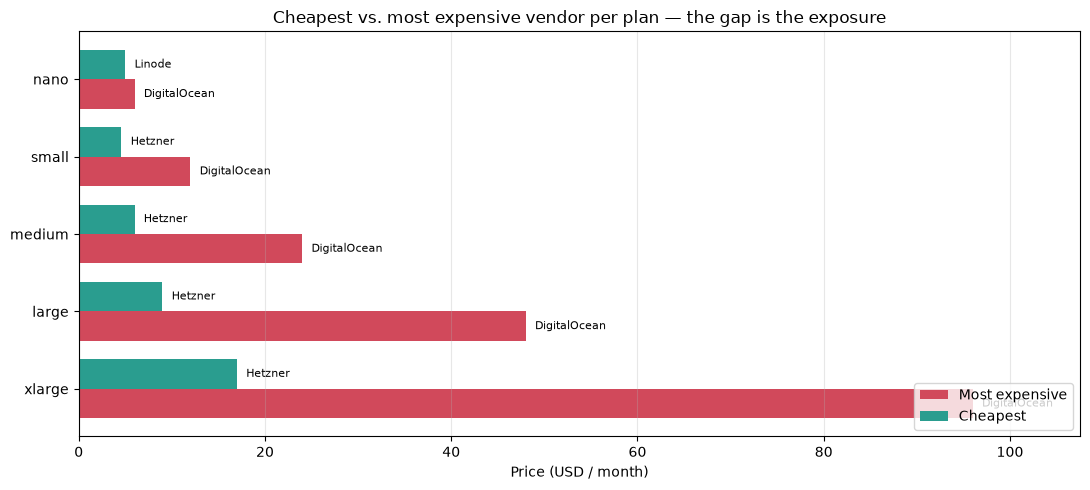

In [6]:
fig, ax = plt.subplots(figsize=(11, 5))
positions = [float(i) for i in range(len(SKU_ORDER))]
bar_h = 0.38

ax.barh([p + bar_h / 2 for p in positions], summary["priciest_price"], height=bar_h,
        color="#d1495b", label="Most expensive")
ax.barh([p - bar_h / 2 for p in positions], summary["cheapest_price"], height=bar_h,
        color="#2a9d8f", label="Cheapest")

for p, sku in zip(positions, SKU_ORDER):
    ax.text(summary.loc[sku, "priciest_price"] + 1, p + bar_h / 2,
            summary.loc[sku, "priciest_vendor"], va="center", fontsize=8)
    ax.text(summary.loc[sku, "cheapest_price"] + 1, p - bar_h / 2,
            summary.loc[sku, "cheapest_vendor"], va="center", fontsize=8)

ax.set_yticks(positions)
ax.set_yticklabels(SKU_ORDER)
ax.invert_yaxis()
ax.set_xlabel("Price (USD / month)")
ax.set_title("Cheapest vs. most expensive vendor per plan — the gap is the exposure")
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.3)
ax.margins(x=0.12)
plt.tight_layout()
plt.show()


## 4 · Coverage and relative position

One more question the numbers force: are we comparing like for like? Hetzner does
not publish a `nano` plan, so the grid is *not* a full rectangle — and a fair
comparison has to notice that.

Below, each vendor's price is expressed as a percentage of the cheapest vendor for
that plan. `100` means "cheapest for this plan"; larger means "you pay more". A
dash is a plan the vendor does not offer, which is a gap rather than a win.


In [7]:
import numpy as np

# Price index: express every vendor's price as a % of the cheapest for that SKU.
cheapest = grid.min(axis=1)
index_pct = (grid.div(cheapest, axis=0) * 100).reindex(
    index=SKU_ORDER, columns=VENDOR_ORDER
)

coverage = grid.notna().sum(axis=0)
print("Plans published per vendor (out of 5):")
print(coverage.rename("plans_published").to_string())
print()
index_pct.round(1)


Plans published per vendor (out of 5):
vendor
DigitalOcean    5
Linode          5
Vultr           5
Hetzner         4



vendor,DigitalOcean,Linode,Vultr,Hetzner
sku,,,,
nano,120.0,100.0,100.0,NaN
small,261.4,261.4,217.9,100.0
medium,400.7,400.7,300.5,100.0
large,533.9,533.9,400.4,100.0
xlarge,565.0,565.0,423.8,100.0


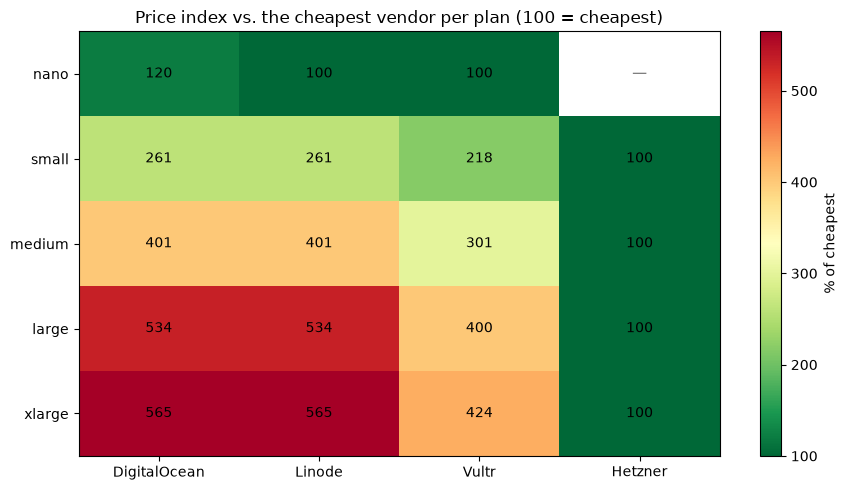

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
masked = np.ma.masked_invalid(index_pct.to_numpy(dtype=float))
im = ax.imshow(masked, cmap="RdYlGn_r", aspect="auto")

ax.set_xticks(range(len(VENDOR_ORDER)))
ax.set_xticklabels(VENDOR_ORDER)
ax.set_yticks(range(len(SKU_ORDER)))
ax.set_yticklabels(SKU_ORDER)
ax.set_title("Price index vs. the cheapest vendor per plan (100 = cheapest)")

for r, sku in enumerate(SKU_ORDER):
    for c, vendor in enumerate(VENDOR_ORDER):
        value = index_pct.loc[sku, vendor]
        if pd.isna(value):
            ax.text(c, r, "—", ha="center", va="center", fontsize=11, color="0.35")
        else:
            ax.text(c, r, f"{value:.0f}", ha="center", va="center", fontsize=10)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("% of cheapest")
plt.tight_layout()
plt.show()


## 5 · How this would run in production

The notebook is the thinking environment; the pipeline underneath it is
deliberately boring, and that is the point.

- **Ingestion is a scheduled no-op.** `seed_from_json()` is idempotent, so it can
  run on a timer without duplicating rows. In production the *input* to that same
  seam is a scraper or a vendor API instead of `sample_data.json` — the storage
  layer does not change.
- **History is kept, not overwritten.** Every observation carries `valid_from` /
  `valid_to`. A new snapshot closes the previous window instead of deleting it, so
  "what did this plan cost three months ago?" stays answerable.
- **Two consumers, one database.** The dashboard serves the current view; this
  notebook serves the analytical one. Neither re-implements the other, and the
  dashboard stays small because the charts live here.
- **What I would add next.** One snapshot per day on a schedule; an alert when
  `spread_pct` moves past a threshold; and — because the cheapest vendor here sits
  far below the pack — an explicit **comparability** check (what the price
  includes) before any of this informs a real decision.


## Summary

### Q&A

- **Where does each vendor sit on price?** On the four plans it offers, Hetzner is
  the cheapest; the gap widens with size, from DigitalOcean/Linode at **261%** of
  Hetzner's price on `small` to **565%** on `xlarge`.
- **Where is the exposure greatest?** The absolute cheapest-to-priciest spread
  grows from **$1.00** on `nano` to **$79.01** on `xlarge`; the relative spread from
  **20%** to **465%**.
- **Is the comparison complete?** No. Hetzner publishes **4 of 5** plans; the other
  three vendors publish all five, so one row of the grid is a gap rather than a
  result.

### Data Analysis Key Findings

- 19 current observations across 4 vendors and 5 SKUs reduce to a comparison grid
  with exactly one open price window per `(vendor, SKU)`.
- Cheapest-vs-priciest spread by plan (USD): `nano` 1.00, `small` 7.41, `medium`
  18.01, `large` 39.01, `xlarge` 79.01 — it grows monotonically with plan size.
- The same spread as a percentage of the cheapest: 20%, 161%, 301%, 434%, 465%.
- Among the three full-coverage vendors, **Vultr** is cheapest at every size
  (100–424% of the reference); DigitalOcean and Linode track each other closely and
  reach 565%.
- Hetzner wins four rows but is absent from `nano` — a coverage gap, not a win.

### Insights or Next Steps

- The ranking is stable across every plan size in this dataset:
  Hetzner < Vultr < Linode ≈ DigitalOcean. A single snapshot shows *what* the
  ranking is; a second snapshot is what would show whether it **holds** — which is
  exactly what the `valid_from` / `valid_to` window is built for.
- Because the cheapest vendor sits so far below the pack, the first question is
  comparability (what each price includes), not the number itself — worth pinning
  down before acting on the spread.
